# Federated IDS — SHAP-based Knowledge Distillation (Thuật toán 1)

Triển khai lại phương pháp **chưng cất tri thức dựa trên SHAP** trong học liên kết
(paper_SHAP.md, Thuật toán 1) cho bài toán IDS trên **CIC-IoT-2023**, dữ liệu **non-IID**
đã chia cho **10 client**.

**Khác biệt so với paper:** paper dùng RandomForest (TreeSHAP); ở đây mỗi client huấn luyện
mô hình **deep learning**:
- Client **1–5**: **GRU**
- Client **6–10**: **Transformer**

Mỗi mẫu là 1 luồng mạng gồm 25 đặc trưng (đã QuantileTransformer chuẩn hoá sẵn).
Đưa vào mô hình chuỗi dưới dạng `(batch, seq_len, 1)` — mỗi đặc trưng là 1 "bước".

## Thuật toán 1 — SHAP-based Knowledge Distillation

Với mỗi client $k = 1..K$:

1. Căn chỉnh dữ liệu: $X_k \rightarrow X_k^{aligned}$
2. Huấn luyện mô hình cục bộ: $f_k = \text{TrainModel}(X_k^{aligned}, y_k)$
3. Tính SHAP: $\Phi_{k,i} = \text{SHAP}(f_k, X_k^{aligned})$
4. Trung bình trị tuyệt đối trên toàn bộ mẫu:
$$\Phi_k = \frac{1}{|X_k^{aligned}|}\sum_{i=1}^{|X_k^{aligned}|} \left|\Phi_{k,i}\right|$$

Tổng hợp toàn cục (trọng số theo kích thước dữ liệu):
$$\Phi_{global} = \sum_{k=1}^{K} w_k \cdot \Phi_k, \qquad w_k = \frac{|X_k|}{\sum_{j=1}^{K}|X_j|}$$

Chọn $n$ đặc trưng quan trọng nhất và huấn luyện lại cục bộ:
$$X_{top} \leftarrow \text{Top}_n(\Phi_{global}), \qquad f_k \leftarrow \text{TrainModel}(X_k^{top}, y_k)$$

> Đây là tổng hợp **feature-importance** (không FedAvg trọng số), nên các mô hình dị kiến trúc
> (GRU/Transformer) vẫn tương thích. Mỗi client được đánh giá trên phần **held-out riêng của mình**
> (giống paper, Bảng 5–7) bằng: Accuracy, Precision/Recall/F1 (macro & weighted), confusion matrix.


In [1]:
# Cell 1 — Environment check + cài shap nếu thiếu
import sys, subprocess, importlib, torch
print("Python:", sys.version.split()[0], "| PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
n_gpu = torch.cuda.device_count()
for i in range(n_gpu):
    print(f"  GPU[{i}]: {torch.cuda.get_device_name(i)}")
assert n_gpu == 2, "Đặt accelerator = 'GPU T4 x2' trong Kaggle notebook settings."

try:
    import shap
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap"], check=True)
    import shap
print("shap:", shap.__version__)

torch.backends.cudnn.benchmark = True
device = torch.device("cuda")


Python: 3.12.13 | PyTorch: 2.10.0+cu128
CUDA available: True
  GPU[0]: Tesla T4
  GPU[1]: Tesla T4
shap: 0.51.0


In [2]:
# Cell 2 — Imports + CONFIG (mọi path & siêu tham số nằm ở đây)
import json, time
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn
import shap

CONFIG = {
    # --- data (Kaggle CSV) ---
    "input_dir":   Path("/kaggle/input/datasets/odixe0502/data-for-10clients"),
    "client_csv":  "client_{k}_train.csv",     # k = 1..10
    "label_col":   "Label",
    "num_classes": 34,
    "n_clients":   10,

    # --- FL / Thuật toán 1 ---
    "top_n":       13,        # ~50% của 25 đặc trưng
    "val_frac":    0.10,      # phần held-out mỗi client để đánh giá + theo dõi hội tụ

    # --- training (tối ưu tốc độ, quan sát hội tụ) ---
    "rounds":       10,       # phase-2 (mô hình cuối, quan sát hội tụ): 10 round x 1 epoch
    "rounds_shap":  3,        # phase-1 chỉ để lấy SHAP -> để nhỏ cho nhanh (tăng =10 nếu muốn)
    "batch_size":   8192,     # batch TỐI ĐA; client nhỏ tự giảm để đủ số bước (xem train_local)
    "min_steps":    40,       # số bước tối thiểu / epoch cho client nhỏ
    "lr":           1e-3,

    # --- SHAP (GradientExplainer, subsample để khả thi trên hàng triệu dòng) ---
    "shap_background": 100,
    "shap_explain":    400,
    "shap_nsamples":   50,

    # --- model ---
    "gru_clients":  [1, 2, 3, 4, 5],
    "tfm_clients":  [6, 7, 8, 9, 10],
    "gru_hidden":   64,
    "gru_layers":   1,
    "tfm_dmodel":   64,
    "tfm_heads":    4,
    "tfm_layers":   2,

    "run_name":     "shap_fl_ids",
    "seed":         42,
}
torch.manual_seed(CONFIG["seed"]); np.random.seed(CONFIG["seed"])

OUT = Path("/kaggle/working") / CONFIG["run_name"]
for sub in ("checkpoints", "logs", "metrics", "artifacts"):
    (OUT / sub).mkdir(parents=True, exist_ok=True)
print("Outputs ->", OUT)


Outputs -> /kaggle/working/shap_fl_ids


## Nạp dữ liệu

Đọc `client_{k}_train.csv` (k = 1..10). Dữ liệu đã chuẩn hoá sẵn — chỉ tách features/label.
Tên 25 đặc trưng lấy trực tiếp từ header CSV để báo cáo SHAP đúng tên.


In [3]:
# Cell 4 — Load 10 client CSV vào RAM (float32) + tên đặc trưng + mapping nhãn
t0 = time.time()
FEATURE_NAMES = None
data = {}   # k -> (X float32 [N,F], y int64 [N])
for k in range(1, CONFIG["n_clients"] + 1):
    path = CONFIG["input_dir"] / CONFIG["client_csv"].format(k=k)
    df = pd.read_csv(path)
    y = df[CONFIG["label_col"]].to_numpy(np.int64)
    Xdf = df.drop(columns=[CONFIG["label_col"]])
    if FEATURE_NAMES is None:
        FEATURE_NAMES = list(Xdf.columns)
    X = Xdf.to_numpy(np.float32)
    data[k] = (X, y)
    del df, Xdf
    print(f"client {k:2d}: X={X.shape} classes={len(np.unique(y))}  ({time.time()-t0:.0f}s)")

N_FEATURES = len(FEATURE_NAMES)
print("N_FEATURES =", N_FEATURES, "| features:", FEATURE_NAMES)

# mapping nhãn (nếu có) để in tên lớp
lm_path = CONFIG["input_dir"] / "label_mapping.csv"
if lm_path.exists():
    lm = pd.read_csv(lm_path)
    ID2LABEL = dict(zip(lm["Encoded_ID"].astype(int), lm["Label_Name"]))
else:
    ID2LABEL = {i: str(i) for i in range(CONFIG["num_classes"])}
print("total train samples:", sum(len(y) for _, y in data.values()))


client  1: X=(31520, 25) classes=8  (0s)
client  2: X=(2211589, 25) classes=21  (7s)
client  3: X=(3728450, 25) classes=25  (19s)
client  4: X=(1920254, 25) classes=8  (24s)
client  5: X=(2531881, 25) classes=14  (32s)
client  6: X=(2686617, 25) classes=5  (40s)
client  7: X=(1824975, 25) classes=11  (46s)
client  8: X=(12759509, 25) classes=28  (85s)
client  9: X=(4354192, 25) classes=19  (98s)
client 10: X=(3965607, 25) classes=14  (110s)
N_FEATURES = 25 | features: ['ack_flag_number', 'AVG', 'Std', 'UDP', 'fin_count', 'Max', 'TCP', 'syn_count', 'Protocol Type', 'Rate', 'IAT', 'syn_flag_number', 'rst_flag_number', 'Tot sum', 'HTTPS', 'ack_count', 'fin_flag_number', 'HTTP', 'rst_count', 'Header_Length', 'psh_flag_number', 'ICMP', 'Time_To_Live', 'ARP', 'DNS']
total train samples: 36014594


In [4]:
# Cell 5 — Split per-client (stratified, an toàn với lớp hiếm) + class weights
def stratified_split(y, val_frac, seed):
    rng = np.random.default_rng(seed)
    tr, va = [], []
    for c in np.unique(y):
        idx = np.where(y == c)[0]; rng.shuffle(idx)
        n_val = int(len(idx) * val_frac)
        if len(idx) < 2:      # lớp chỉ 1 mẫu -> để hết vào train
            n_val = 0
        va.append(idx[:n_val]); tr.append(idx[n_val:])
    return np.concatenate(tr), np.concatenate(va)

def class_weights(y, num_classes):
    # weighted CrossEntropy: cân bằng theo tần suất, lớp vắng mặt -> 0
    w = np.zeros(num_classes, dtype=np.float32)
    cls, cnt = np.unique(y, return_counts=True)
    w[cls] = (len(y) / (len(cls) * cnt)).astype(np.float32)
    return torch.tensor(w, device=device)

SPLITS = {k: stratified_split(data[k][1], CONFIG["val_frac"], CONFIG["seed"] + k)
          for k in data}
for k in data:
    print(f"client {k:2d}: train={len(SPLITS[k][0]):>9d}  val={len(SPLITS[k][1]):>8d}")


client  1: train=    28371  val=    3149
client  2: train=  1990440  val=  221149
client  3: train=  3355617  val=  372833
client  4: train=  1728232  val=  192022
client  5: train=  2278699  val=  253182
client  6: train=  2417957  val=  268660
client  7: train=  1642482  val=  182493
client  8: train= 11483570  val= 1275939
client  9: train=  3918779  val=  435413
client 10: train=  3569053  val=  396554


In [5]:
# Cell 6 — Model definitions (input: (B, seq_len, 1))
class GRUClassifier(nn.Module):
    def __init__(self, seq_len, hidden, layers, num_classes):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=hidden, num_layers=layers,
                          batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.LayerNorm(2 * hidden),
                                  nn.Linear(2 * hidden, num_classes))
    def forward(self, x):                 # x: (B, seq, 1)
        out, _ = self.gru(x)              # (B, seq, 2H)
        return self.head(out.mean(dim=1)) # mean-pool over seq

class TransformerClassifier(nn.Module):
    def __init__(self, seq_len, d_model, heads, layers, num_classes):
        super().__init__()
        self.proj = nn.Linear(1, d_model)
        self.pos = nn.Parameter(torch.zeros(1, seq_len, d_model))
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=heads,
                                         dim_feedforward=2 * d_model,
                                         batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(enc, num_layers=layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model),
                                  nn.Linear(d_model, num_classes))
    def forward(self, x):                 # x: (B, seq, 1)
        h = self.proj(x) + self.pos       # (B, seq, d)
        h = self.encoder(h)
        return self.head(h.mean(dim=1))

def build_model(k, seq_len):
    if k in CONFIG["gru_clients"]:
        m = GRUClassifier(seq_len, CONFIG["gru_hidden"], CONFIG["gru_layers"],
                          CONFIG["num_classes"])
        fam = "GRU"
    else:
        m = TransformerClassifier(seq_len, CONFIG["tfm_dmodel"], CONFIG["tfm_heads"],
                                  CONFIG["tfm_layers"], CONFIG["num_classes"])
        fam = "Transformer"
    m = m.to(device)
    if torch.cuda.device_count() > 1:
        m = nn.DataParallel(m)
    return m, fam

def unwrap(m):
    return m.module if isinstance(m, nn.DataParallel) else m
FAMILY = {k: ("GRU" if k in CONFIG["gru_clients"] else "Transformer") for k in range(1, 11)}
print(FAMILY)


{1: 'GRU', 2: 'GRU', 3: 'GRU', 4: 'GRU', 5: 'GRU', 6: 'Transformer', 7: 'Transformer', 8: 'Transformer', 9: 'Transformer', 10: 'Transformer'}


In [6]:
# Cell 7 — Train / eval helpers (AMP + DataParallel) + SHAP importance
def run_epoch(model, Xg, yg, criterion, optimizer, scaler, bs, train):
    n = Xg.shape[0]
    perm = torch.randperm(n, device=Xg.device) if train else torch.arange(n, device=Xg.device)
    model.train(train)
    tot_loss, correct = 0.0, 0
    for i in range(0, n, bs):
        idx = perm[i:i + bs]
        xb, yb = Xg[idx], yg[idx]
        if train:
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda"):
                out = model(xb); loss = criterion(out, yb)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else:
            with torch.no_grad(), torch.amp.autocast("cuda"):
                out = model(xb); loss = criterion(out, yb)
        tot_loss += loss.item() * yb.size(0)
        correct  += (out.argmax(1) == yb).sum().item()
    return tot_loss / n, correct / n

@torch.no_grad()
def predict(model, Xg, bs):
    model.eval(); preds = []
    for i in range(0, Xg.shape[0], bs):
        with torch.amp.autocast("cuda"):
            out = model(Xg[i:i + bs])
        preds.append(out.argmax(1).cpu())
    return torch.cat(preds).numpy()

def train_local(model, Xg_tr, yg_tr, Xg_va, yg_va, w, rounds, bs, lr):
    # Thuật toán 1: f_k = TrainModel(X_k, y_k). 'round' = 1 epoch; log để xem hội tụ.
    # batch hiệu dụng: client nhỏ giảm batch để đủ ~min_steps bước/epoch (không vượt 'bs').
    ebs = int(min(bs, max(256, Xg_tr.shape[0] // CONFIG["min_steps"])))
    criterion = nn.CrossEntropyLoss(weight=w)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler("cuda")
    hist = []
    for r in range(1, rounds + 1):
        tr_loss, tr_acc = run_epoch(model, Xg_tr, yg_tr, criterion, optimizer, scaler, ebs, True)
        va_loss, va_acc = run_epoch(model, Xg_va, yg_va, criterion, optimizer, scaler, ebs, False)
        hist.append({"round": r, "train_loss": tr_loss, "train_acc": tr_acc,
                     "val_loss": va_loss, "val_acc": va_acc})
        print(f"    round {r:2d}/{rounds}  bs {ebs}  train_loss {tr_loss:.4f} acc {tr_acc:.4f}"
              f"  |  val_loss {va_loss:.4f} acc {va_acc:.4f}")
    return hist

def shap_importance(model, Xg_pool, cfg):
    # Phi_k = (1/|X|) sum_i |SHAP(f_k, x_i)| ; đa lớp -> giải thích lớp dự đoán (ranked_outputs=1).
    m = unwrap(model).eval()
    n = Xg_pool.shape[0]
    g = torch.Generator(device=Xg_pool.device).manual_seed(cfg["seed"])
    bg = Xg_pool[torch.randperm(n, device=Xg_pool.device, generator=g)[:cfg["shap_background"]]].float()
    ex = Xg_pool[torch.randperm(n, device=Xg_pool.device, generator=g)[:cfg["shap_explain"]]].float()
    # cuDNN RNN không cho backward ở eval mode -> TẮT cuDNN khi tính SHAP (GRU dùng kernel native).
    prev = torch.backends.cudnn.enabled
    torch.backends.cudnn.enabled = False
    try:
        expl = shap.GradientExplainer(m, bg)
        sv = expl.shap_values(ex, nsamples=cfg["shap_nsamples"], ranked_outputs=1)
    finally:
        torch.backends.cudnn.enabled = prev
    if isinstance(sv, tuple):   # (values, indexes) khi ranked_outputs được set
        sv = sv[0]
    arr = np.asarray(sv[0] if isinstance(sv, list) else sv)   # (n_ex, seq, 1[, ...])
    phi = np.abs(arr).mean(axis=0)                 # bỏ trục mẫu
    phi = phi.reshape(arr.shape[1], -1).mean(axis=1)  # -> (seq,)
    return phi.astype(np.float64)


## Phase 1 — Huấn luyện cục bộ + tính SHAP $\Phi_k$

Mỗi client huấn luyện mô hình trên **toàn bộ 25 đặc trưng**, rồi tính vector tầm quan trọng
$$\Phi_k = \frac{1}{|X_k|}\sum_{i}\left|\Phi_{k,i}\right|.$$
(Phase-1 chỉ nhằm lấy SHAP nên chạy `rounds_shap` epoch cho nhanh.)


In [7]:
# Cell 9 — Phase 1: train (25 features) + SHAP cho từng client
PHI = np.zeros((CONFIG["n_clients"], N_FEATURES), dtype=np.float64)   # Phi_k
phase1_hist = {}
for k in range(1, CONFIG["n_clients"] + 1):
    print(f"[Phase1] client {k} ({FAMILY[k]})")
    X, y = data[k]
    tr, va = SPLITS[k]
    Xg_tr = torch.from_numpy(X[tr]).to(device).unsqueeze(-1); yg_tr = torch.from_numpy(y[tr]).to(device)
    Xg_va = torch.from_numpy(X[va]).to(device).unsqueeze(-1); yg_va = torch.from_numpy(y[va]).to(device)
    w = class_weights(y[tr], CONFIG["num_classes"])

    model, _ = build_model(k, seq_len=N_FEATURES)
    phase1_hist[k] = train_local(model, Xg_tr, yg_tr, Xg_va, yg_va, w,
                                 CONFIG["rounds_shap"], CONFIG["batch_size"], CONFIG["lr"])
    PHI[k - 1] = shap_importance(model, Xg_tr, CONFIG)
    top_local = [FEATURE_NAMES[i] for i in np.argsort(PHI[k - 1])[::-1][:5]]
    print(f"    Phi_{k} top-5: {top_local}")

    del Xg_tr, yg_tr, Xg_va, yg_va, model
    torch.cuda.empty_cache()

np.save(OUT / "metrics" / "phi_per_client.npy", PHI)
print("PHI shape:", PHI.shape)


[Phase1] client 1 (GRU)
    round  1/3  bs 709  train_loss 2.3300 acc 0.1744  |  val_loss 1.6671 acc 0.1867
    round  2/3  bs 709  train_loss 1.9636 acc 0.4079  |  val_loss 1.7455 acc 0.2048
    round  3/3  bs 709  train_loss 1.7940 acc 0.2808  |  val_loss 1.6163 acc 0.4659
    Phi_1 top-5: ['HTTPS', 'TCP', 'syn_flag_number', 'psh_flag_number', 'HTTP']
[Phase1] client 2 (GRU)
    round  1/3  bs 8192  train_loss 2.2787 acc 0.4117  |  val_loss 1.4248 acc 0.5057
    round  2/3  bs 8192  train_loss 1.5789 acc 0.6387  |  val_loss 0.9056 acc 0.7103
    round  3/3  bs 8192  train_loss 1.2836 acc 0.7424  |  val_loss 0.6942 acc 0.7550
    Phi_2 top-5: ['UDP', 'psh_flag_number', 'ack_flag_number', 'AVG', 'TCP']
[Phase1] client 3 (GRU)
    round  1/3  bs 8192  train_loss 2.7175 acc 0.6259  |  val_loss 1.4901 acc 0.6936
    round  2/3  bs 8192  train_loss 2.1919 acc 0.7687  |  val_loss 0.7501 acc 0.8334
    round  3/3  bs 8192  train_loss 1.8338 acc 0.8415  |  val_loss 0.5652 acc 0.8659
    Phi_3

## Tổng hợp toàn cục $\Phi_{global}$ + chọn Top-$n$

$$\Phi_{global} = \sum_{k=1}^{K} w_k \Phi_k, \quad w_k = \frac{|X_k|}{\sum_j |X_j|}, \qquad
X_{top} \leftarrow \text{Top}_n(\Phi_{global}).$$


In [8]:
# Cell 11 — Aggregate Phi_global (trọng số theo |X_k|) + chọn top-n
sizes = np.array([len(data[k][1]) for k in range(1, CONFIG["n_clients"] + 1)], dtype=np.float64)
w_k = sizes / sizes.sum()
PHI_GLOBAL = (w_k[:, None] * PHI).sum(axis=0)           # (N_FEATURES,)

order = np.argsort(PHI_GLOBAL)[::-1]
TOP_IDX = np.sort(order[:CONFIG["top_n"]])              # giữ thứ tự cột gốc
TOP_NAMES = [FEATURE_NAMES[i] for i in TOP_IDX]
print("w_k =", np.round(w_k, 4))
print(f"\nTop-{CONFIG['top_n']} features (Phi_global):")
for i in order[:CONFIG["top_n"]]:
    print(f"  {FEATURE_NAMES[i]:<16s} {PHI_GLOBAL[i]:.6f}")

json.dump({"phi_global": PHI_GLOBAL.tolist(), "feature_names": FEATURE_NAMES,
           "top_idx": TOP_IDX.tolist(), "top_names": TOP_NAMES, "w_k": w_k.tolist()},
          open(OUT / "metrics" / "global_feature_profile.json", "w"), indent=2)


w_k = [0.0009 0.0614 0.1035 0.0533 0.0703 0.0746 0.0507 0.3543 0.1209 0.1101]

Top-13 features (Phi_global):
  syn_flag_number  1.338136
  TCP              1.167641
  Protocol Type    1.162749
  UDP              0.771974
  ICMP             0.630687
  ack_count        0.595515
  Tot sum          0.558136
  syn_count        0.519507
  psh_flag_number  0.389220
  Header_Length    0.370050
  AVG              0.366210
  ack_flag_number  0.365504
  HTTPS            0.316406


## Phase 2 — Huấn luyện lại trên $X_k^{top}$ + đánh giá per-client

$$f_k \leftarrow \text{TrainModel}(X_k^{top}, y_k), \qquad \hat{y}_k = f_k(X_k^{top}).$$

Metric (paper, ct. 14–17):
$$Accuracy=\frac{\#đúng}{\#tổng},\ \ Precision=\frac{TP}{TP+FP},\ \
Recall=\frac{TP}{TP+FN},\ \ F1=2\cdot\frac{P\cdot R}{P+R}.$$
Mỗi client train `rounds`=10 (1 epoch/round) và đánh giá trên phần held-out riêng.


In [9]:
# Cell 13 — Phase 2: retrain trên top-n + đánh giá + lưu checkpoint
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

def scores(y_true, y_pred):
    return {
        "accuracy":           float(accuracy_score(y_true, y_pred)),
        "macro_precision":    float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall":       float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_f1":           float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "weighted_recall":    float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "weighted_f1":        float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }

phase2_hist, RESULTS, CM = {}, {}, {}
for k in range(1, CONFIG["n_clients"] + 1):
    print(f"[Phase2] client {k} ({FAMILY[k]}) -> top-{CONFIG['top_n']} features")
    X, y = data[k]
    Xtop = X[:, TOP_IDX]
    tr, va = SPLITS[k]
    Xg_tr = torch.from_numpy(Xtop[tr]).to(device).unsqueeze(-1); yg_tr = torch.from_numpy(y[tr]).to(device)
    Xg_va = torch.from_numpy(Xtop[va]).to(device).unsqueeze(-1); yg_va = torch.from_numpy(y[va]).to(device)
    w = class_weights(y[tr], CONFIG["num_classes"])

    model, fam = build_model(k, seq_len=CONFIG["top_n"])
    phase2_hist[k] = train_local(model, Xg_tr, yg_tr, Xg_va, yg_va, w,
                                 CONFIG["rounds"], CONFIG["batch_size"], CONFIG["lr"])

    y_pred = predict(model, Xg_va, CONFIG["batch_size"]); y_true = y[va]
    RESULTS[k] = {"family": fam, "n_train": int(len(tr)), "n_val": int(len(va)),
                  "classes": sorted(set(int(c) for c in np.unique(y_true))),
                  **scores(y_true, y_pred)}
    present = sorted(set(int(c) for c in np.unique(np.concatenate([y_true, y_pred]))))
    CM[k] = {"labels": present,
             "matrix": confusion_matrix(y_true, y_pred, labels=present).tolist()}
    rep = classification_report(y_true, y_pred, labels=present, output_dict=True, zero_division=0)
    json.dump(rep, open(OUT / "metrics" / f"client_{k}_report.json", "w"), indent=2, default=float)
    torch.save(unwrap(model).state_dict(), OUT / "checkpoints" / f"client_{k}_best.pt")
    print(f"    acc {RESULTS[k]['accuracy']:.4f}  macroF1 {RESULTS[k]['macro_f1']:.4f}"
          f"  weightedF1 {RESULTS[k]['weighted_f1']:.4f}")

    del Xg_tr, yg_tr, Xg_va, yg_va, model
    torch.cuda.empty_cache()


[Phase2] client 1 (GRU) -> top-13 features
    round  1/10  bs 709  train_loss 2.2332 acc 0.3030  |  val_loss 1.6007 acc 0.4767
    round  2/10  bs 709  train_loss 1.8691 acc 0.1328  |  val_loss 1.7244 acc 0.0762
    round  3/10  bs 709  train_loss 1.7505 acc 0.3520  |  val_loss 1.5600 acc 0.5948
    round  4/10  bs 709  train_loss 1.7165 acc 0.3882  |  val_loss 1.6633 acc 0.0864
    round  5/10  bs 709  train_loss 1.6749 acc 0.0950  |  val_loss 1.5651 acc 0.1978
    round  6/10  bs 709  train_loss 1.6202 acc 0.3748  |  val_loss 1.6892 acc 0.1162
    round  7/10  bs 709  train_loss 1.5224 acc 0.2043  |  val_loss 1.4674 acc 0.4605
    round  8/10  bs 709  train_loss 1.4484 acc 0.3104  |  val_loss 1.4627 acc 0.3217
    round  9/10  bs 709  train_loss 1.3568 acc 0.3480  |  val_loss 1.5101 acc 0.3258
    round 10/10  bs 709  train_loss 1.2496 acc 0.1809  |  val_loss 1.4366 acc 0.1982
    acc 0.1982  macroF1 0.2392  weightedF1 0.2787
[Phase2] client 2 (GRU) -> top-13 features
    round  1/1

In [10]:
# Cell 14 — Gộp kết quả + summary.json
summary = {
    "config": {kk: (str(v) if isinstance(v, Path) else v) for kk, v in CONFIG.items()},
    "top_features": TOP_NAMES,
    "results_per_client": RESULTS,
    "phase1_history": phase1_hist,
    "phase2_history": phase2_hist,
}
json.dump(summary, open(OUT / "metrics" / "summary.json", "w"), indent=2, default=float)
json.dump(CM, open(OUT / "metrics" / "confusion_matrices.json", "w"), indent=2)

macro = np.mean([RESULTS[k]["accuracy"] for k in RESULTS])
wf1   = np.mean([RESULTS[k]["weighted_f1"] for k in RESULTS])
print(f"Mean per-client accuracy = {macro:.4f} | mean weighted-F1 = {wf1:.4f}")
print("\nclient | family      |   acc   | macroF1 | weightF1")
for k in RESULTS:
    r = RESULTS[k]
    print(f"  {k:2d}   | {r['family']:<11s} | {r['accuracy']:.4f} | {r['macro_f1']:.4f} | {r['weighted_f1']:.4f}")


Mean per-client accuracy = 0.8355 | mean weighted-F1 = 0.8534

client | family      |   acc   | macroF1 | weightF1
   1   | GRU         | 0.1982 | 0.2392 | 0.2787
   2   | GRU         | 0.8145 | 0.5482 | 0.8262
   3   | GRU         | 0.9143 | 0.3293 | 0.9226
   4   | GRU         | 0.9727 | 0.6384 | 0.9791
   5   | GRU         | 0.9742 | 0.4422 | 0.9808
   6   | Transformer | 0.9952 | 0.7772 | 0.9969
   7   | Transformer | 0.9704 | 0.6451 | 0.9788
   8   | Transformer | 0.5684 | 0.3662 | 0.6126
   9   | Transformer | 0.9605 | 0.5216 | 0.9676
  10   | Transformer | 0.9866 | 0.5761 | 0.9908


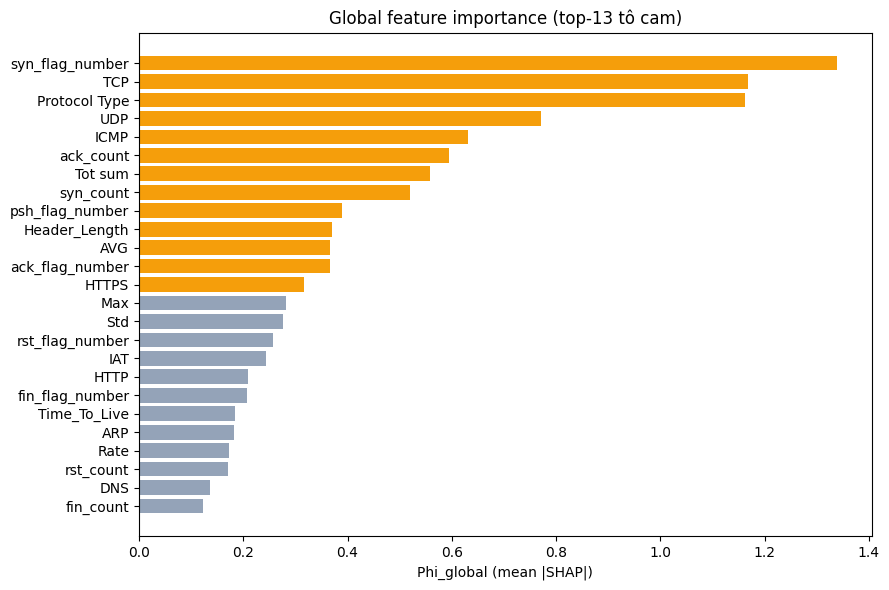

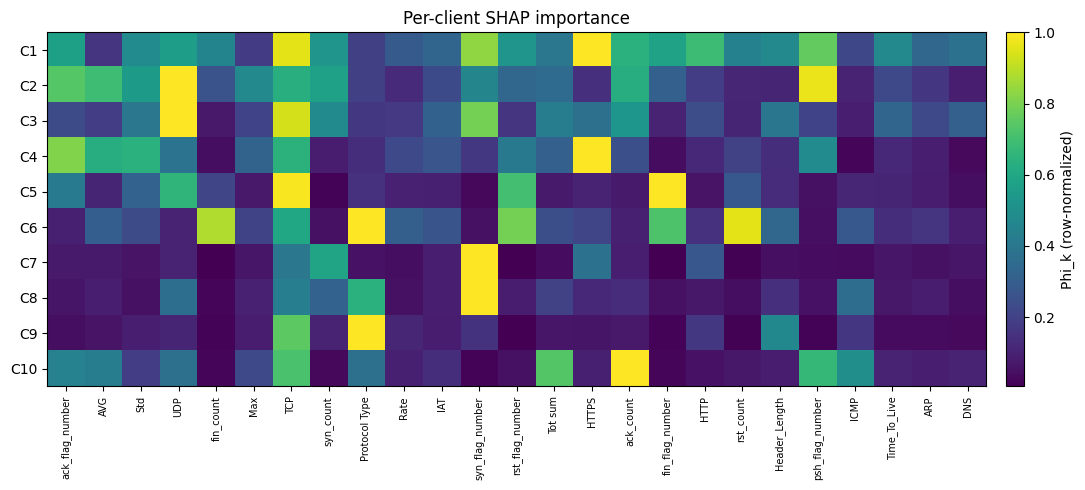

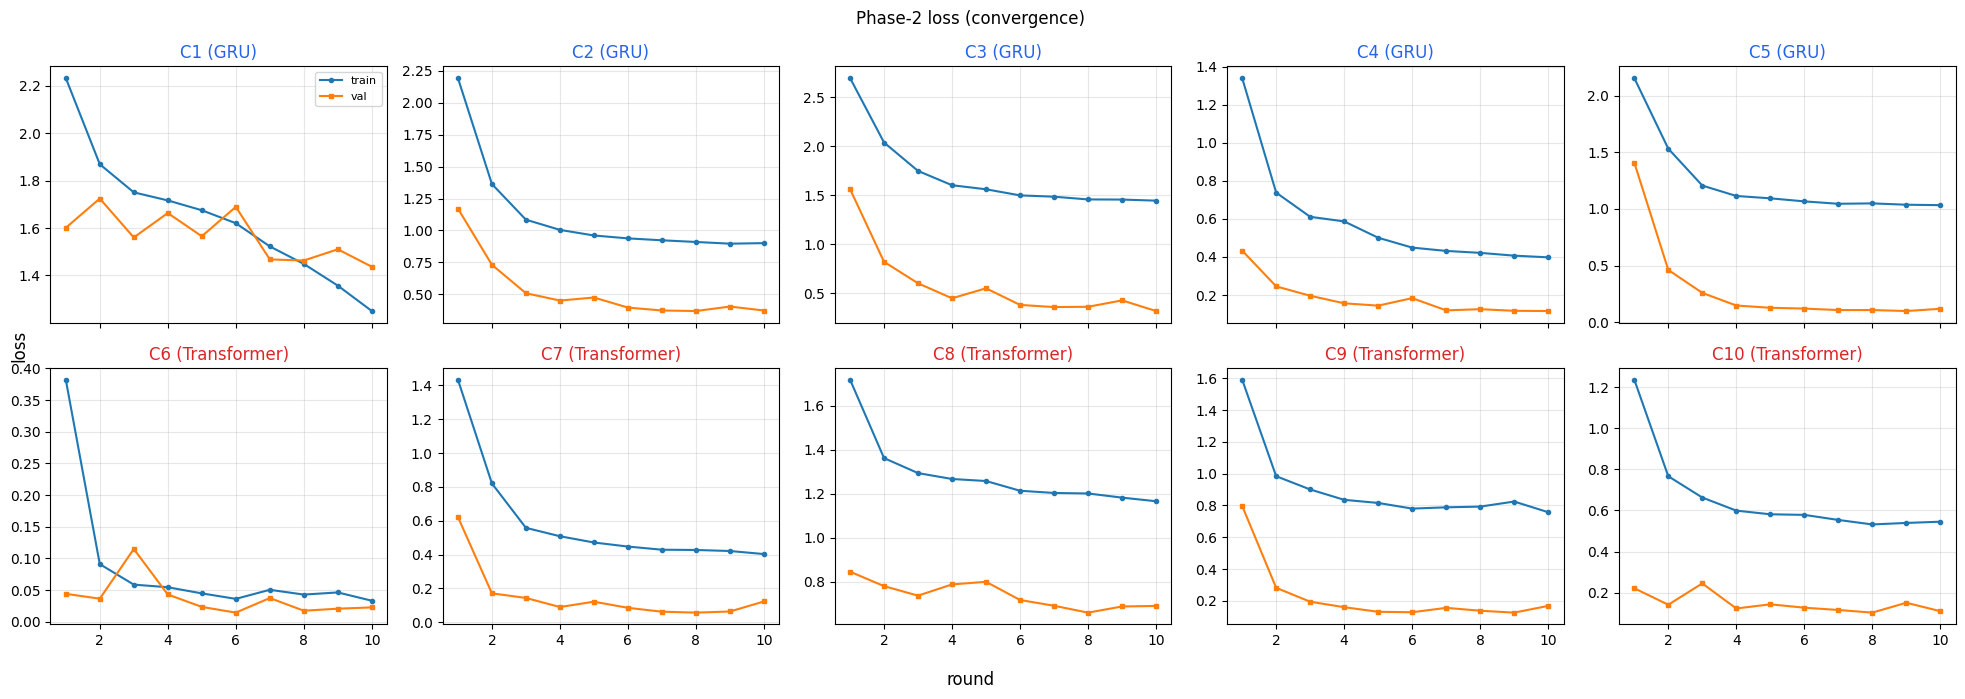

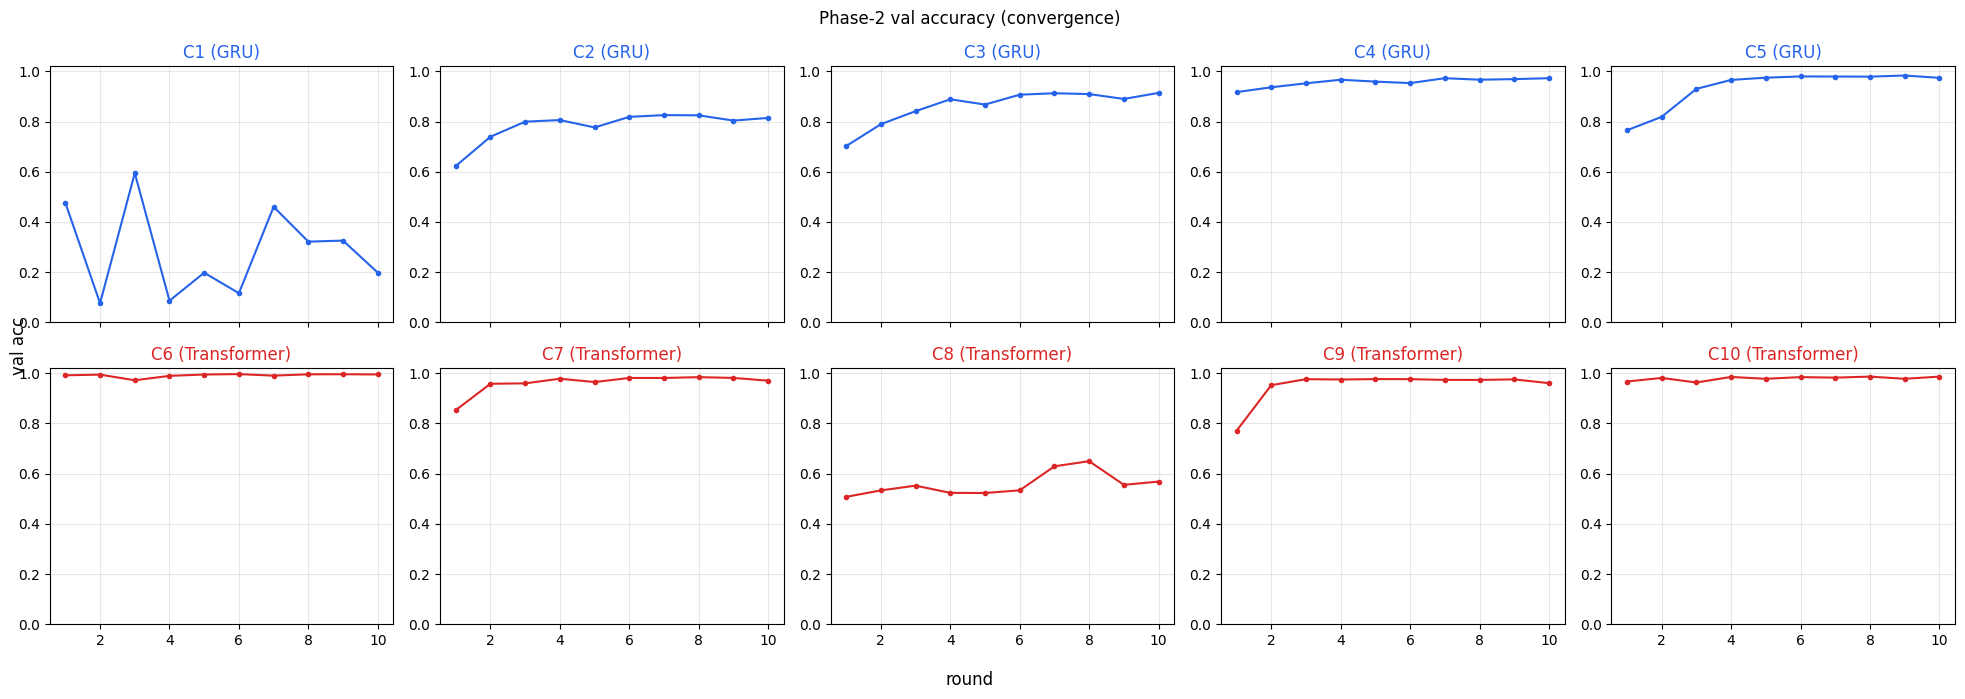

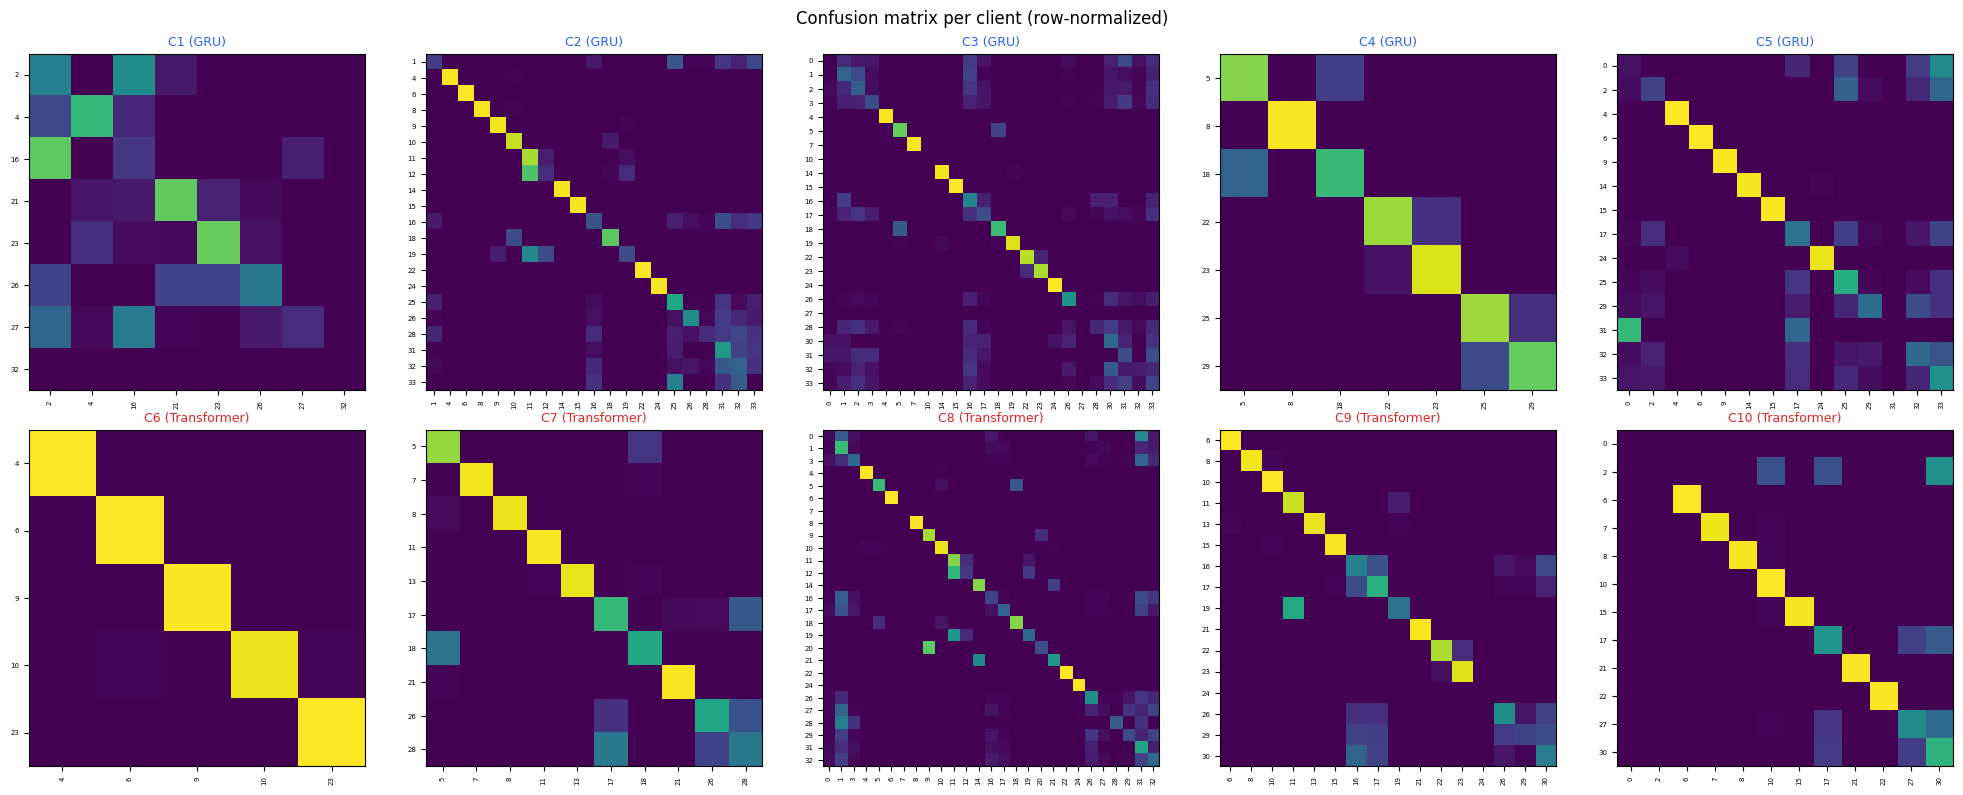

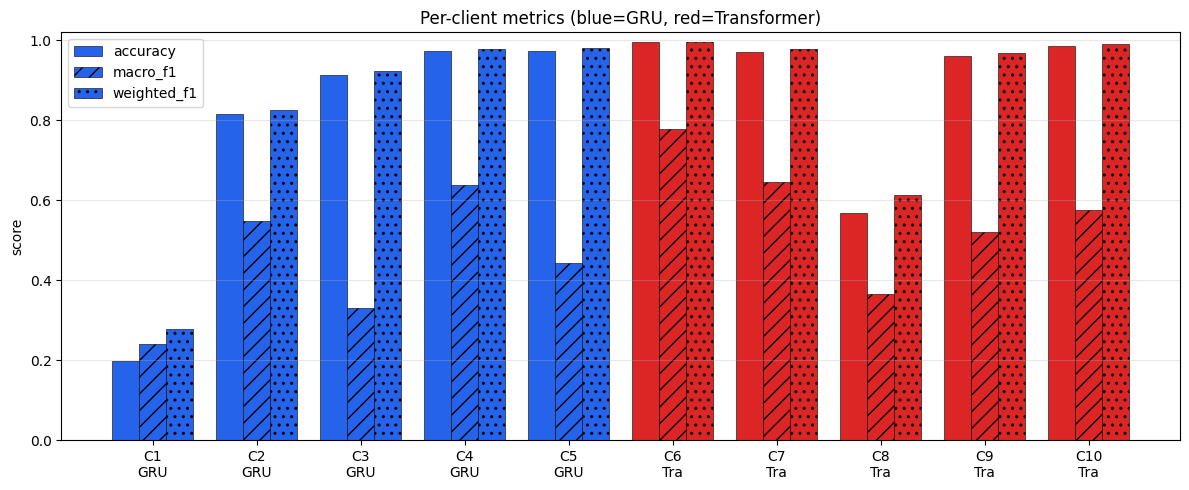

Saved artifacts -> /kaggle/working/shap_fl_ids/artifacts


In [11]:
# Cell 15 — Diagnostic plots (lưu PNG + hiển thị)
import matplotlib.pyplot as plt
ART = OUT / "artifacts"
CLIENTS = list(range(1, CONFIG["n_clients"] + 1))
COL = {"GRU": "#2563eb", "Transformer": "#dc2626"}

# (A) SHAP toàn cục — Phi_global theo tên đặc trưng, tô đậm top-n
oq = np.argsort(PHI_GLOBAL)[::-1]
plt.figure(figsize=(9, 6))
colors = ["#f59e0b" if i in set(TOP_IDX) else "#94a3b8" for i in oq]
plt.barh([FEATURE_NAMES[i] for i in oq][::-1], PHI_GLOBAL[oq][::-1], color=colors[::-1])
plt.xlabel("Phi_global (mean |SHAP|)"); plt.title(f"Global feature importance (top-{CONFIG['top_n']} tô cam)")
plt.tight_layout(); plt.savefig(ART / "shap_global_importance.png", dpi=120); plt.show()

# (B) Heatmap Phi_k (chuẩn hoá theo hàng) : client x feature
Pn = PHI / PHI.max(axis=1, keepdims=True).clip(min=1e-12)
plt.figure(figsize=(11, 5))
plt.imshow(Pn, aspect="auto", cmap="viridis")
plt.colorbar(fraction=0.025, pad=0.02, label="Phi_k (row-normalized)")
plt.yticks(range(CONFIG["n_clients"]), [f"C{k}" for k in CLIENTS])
plt.xticks(range(N_FEATURES), FEATURE_NAMES, rotation=90, fontsize=7)
plt.title("Per-client SHAP importance"); plt.tight_layout()
plt.savefig(ART / "shap_per_client_heatmap.png", dpi=120); plt.show()

# (C) Loss curve hội tụ (phase-2) — lưới 2x5
fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharex=True)
for ax, k in zip(axes.ravel(), CLIENTS):
    h = phase2_hist[k]; rr = [d["round"] for d in h]
    ax.plot(rr, [d["train_loss"] for d in h], "-o", ms=3, label="train")
    ax.plot(rr, [d["val_loss"] for d in h], "-s", ms=3, label="val")
    ax.set_title(f"C{k} ({FAMILY[k]})", color=COL[FAMILY[k]]); ax.grid(alpha=.3)
    if k == 1: ax.legend(fontsize=8)
fig.suptitle("Phase-2 loss (convergence)"); fig.supxlabel("round"); fig.supylabel("loss")
plt.tight_layout(); plt.savefig(ART / "loss_curve.png", dpi=120); plt.show()

# (D) Accuracy curve (phase-2) — lưới 2x5
fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharex=True)
for ax, k in zip(axes.ravel(), CLIENTS):
    h = phase2_hist[k]; rr = [d["round"] for d in h]
    ax.plot(rr, [d["val_acc"] for d in h], "-o", ms=3, color=COL[FAMILY[k]])
    ax.set_title(f"C{k} ({FAMILY[k]})", color=COL[FAMILY[k]]); ax.grid(alpha=.3); ax.set_ylim(0, 1.02)
fig.suptitle("Phase-2 val accuracy (convergence)"); fig.supxlabel("round"); fig.supylabel("val acc")
plt.tight_layout(); plt.savefig(ART / "metric_curve.png", dpi=120); plt.show()

# (E) Confusion matrix per-client (row-normalized) — lưới 2x5
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, k in zip(axes.ravel(), CLIENTS):
    cm = np.array(CM[k]["matrix"], dtype=float); labs = CM[k]["labels"]
    cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
    ax.imshow(cmn, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"C{k} ({FAMILY[k]})", color=COL[FAMILY[k]], fontsize=9)
    ax.set_xticks(range(len(labs))); ax.set_yticks(range(len(labs)))
    ax.set_xticklabels(labs, fontsize=5, rotation=90); ax.set_yticklabels(labs, fontsize=5)
fig.suptitle("Confusion matrix per client (row-normalized)")
plt.tight_layout(); plt.savefig(ART / "confusion_matrix.png", dpi=120); plt.show()

# (F) So sánh per-client (accuracy / macroF1 / weightedF1), màu theo họ mô hình
x = np.arange(len(CLIENTS)); wbar = 0.26
fig, ax = plt.subplots(figsize=(12, 5))
for off, m, hatch in zip((-wbar, 0, wbar), ("accuracy", "macro_f1", "weighted_f1"), (None, "//", "..")):
    ax.bar(x + off, [RESULTS[k][m] for k in CLIENTS], wbar, label=m, hatch=hatch,
           color=[COL[FAMILY[k]] for k in CLIENTS], edgecolor="k", linewidth=.4)
ax.set_xticks(x); ax.set_xticklabels([f"C{k}\n{FAMILY[k][:3]}" for k in CLIENTS])
ax.set_ylim(0, 1.02); ax.set_ylabel("score"); ax.set_title("Per-client metrics (blue=GRU, red=Transformer)")
ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.savefig(ART / "per_group_metrics.png", dpi=120); plt.show()
print("Saved artifacts ->", ART)
